In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
 
# Sklearn — preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
 
# Sklearn — ML models
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import SVC, SVR
 
# Sklearn — metrics
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    mean_squared_error, r2_score, mean_absolute_error
)
 
# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, Flatten, MaxPooling1D, Reshape
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
 
# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
 
# Saving models
import joblib
import os
 
print("✅ All libraries imported successfully!")
print(f"   TensorFlow version : {tf.__version__}")
print(f"   Scikit-learn version: {__import__('sklearn').__version__}")

✅ All libraries imported successfully!
   TensorFlow version : 2.21.0
   Scikit-learn version: 1.7.2


In [2]:
import pandas as pd

# Load datasets
fert_df = pd.read_csv(r"C:\Users\HP\Downloads\agri\data\raw\fertilizer.csv.csv")
yield_df = pd.read_csv(r"C:\Users\HP\Downloads\agri\data\raw\yield_df.csv")
prod_df = pd.read_csv(r"C:\Users\HP\Downloads\agri\data\raw\crop_production.csv")
rec_df = pd.read_csv(r"C:\Users\HP\Downloads\agri\data\raw\Crop_recommendation.csv")

datasets = {
    "Fertilizer": fert_df,
    "Yield": yield_df,
    "Crop Production": prod_df,
    "Crop Recommendation": rec_df
}

for name, df in datasets.items():

    print("\n" + "=" * 80)
    print(f"{name.upper():^80}")
    print("=" * 80)

    print(f"{'Shape':<20}: {df.shape[0]} rows × {df.shape[1]} columns")
    print(f"{'Missing Values':<20}: {df.isnull().sum().sum()}")

    print(f"\n{'Columns':<20}:")
    for i, col in enumerate(df.columns, start=1):
        print(f"   {i:2}. {col}")

    print("\nSample Data:")
    print("-" * 80)
    print(df.head(3).to_string(index=False))
    print("-" * 80)


                                   FERTILIZER                                   
Shape               : 99 rows × 9 columns
Missing Values      : 0

Columns             :
    1. Temparature
    2. Humidity 
    3. Moisture
    4. Soil Type
    5. Crop Type
    6. Nitrogen
    7. Potassium
    8. Phosphorous
    9. Fertilizer Name

Sample Data:
--------------------------------------------------------------------------------
 Temparature  Humidity   Moisture Soil Type Crop Type  Nitrogen  Potassium  Phosphorous Fertilizer Name
          26         52        38     Sandy     Maize        37          0            0            Urea
          29         52        45     Loamy Sugarcane        12          0           36             DAP
          34         65        62     Black    Cotton         7          9           30        14-35-14
--------------------------------------------------------------------------------

                                     YIELD                                 

In [3]:
# ── 3A. Fertilizer ────────────────────────────────────────────────────────
fert_df.columns = fert_df.columns.str.strip()          # remove spaces
fert_df.rename(columns={"Temparature": "Temperature",  # fix typos
                         "Humidity ":  "Humidity"}, inplace=True)
fert_df.dropna(inplace=True)
fert_df.drop_duplicates(inplace=True)
print("✅ Fertilizer cleaned:", fert_df.shape)
print("   Columns:", list(fert_df.columns))
 
# ── 3B. Yield ──────────────────────────────────────────────────────────────
yield_df.columns = yield_df.columns.str.strip()
yield_df["Season"] = yield_df["Season"].str.strip()     # remove trailing spaces
yield_df.dropna(subset=["Yield"], inplace=True)         # drop rows without target
yield_df.drop_duplicates(inplace=True)
# Clip extreme outliers (> 99th percentile)
upper = yield_df["Yield"].quantile(0.99)
yield_df = yield_df[yield_df["Yield"] <= upper].copy()
print("\n✅ Yield cleaned:", yield_df.shape)
 
# ── 3C. Crop Production ───────────────────────────────────────────────────
prod_df.columns = prod_df.columns.str.strip()
prod_df["Season"] = prod_df["Season"].str.strip()
prod_df.dropna(subset=["Production"], inplace=True)
prod_df.drop_duplicates(inplace=True)
print("\n✅ Crop Production cleaned:", prod_df.shape)
 
# ── 3D. Crop Recommendation (primary ML training data) ────────────────────
rec_df.columns = rec_df.columns.str.strip()
rec_df.dropna(inplace=True)
rec_df.drop_duplicates(inplace=True)
print("\n✅ Crop Recommendation cleaned:", rec_df.shape)
print("   Crops:", sorted(rec_df["label"].unique()))


✅ Fertilizer cleaned: (99, 9)
   Columns: ['Temperature', 'Humidity', 'Moisture', 'Soil Type', 'Crop Type', 'Nitrogen', 'Potassium', 'Phosphorous', 'Fertilizer Name']

✅ Yield cleaned: (19492, 10)

✅ Crop Production cleaned: (242361, 7)

✅ Crop Recommendation cleaned: (2200, 8)
   Crops: ['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee', 'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize', 'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'pomegranate', 'rice', 'watermelon']


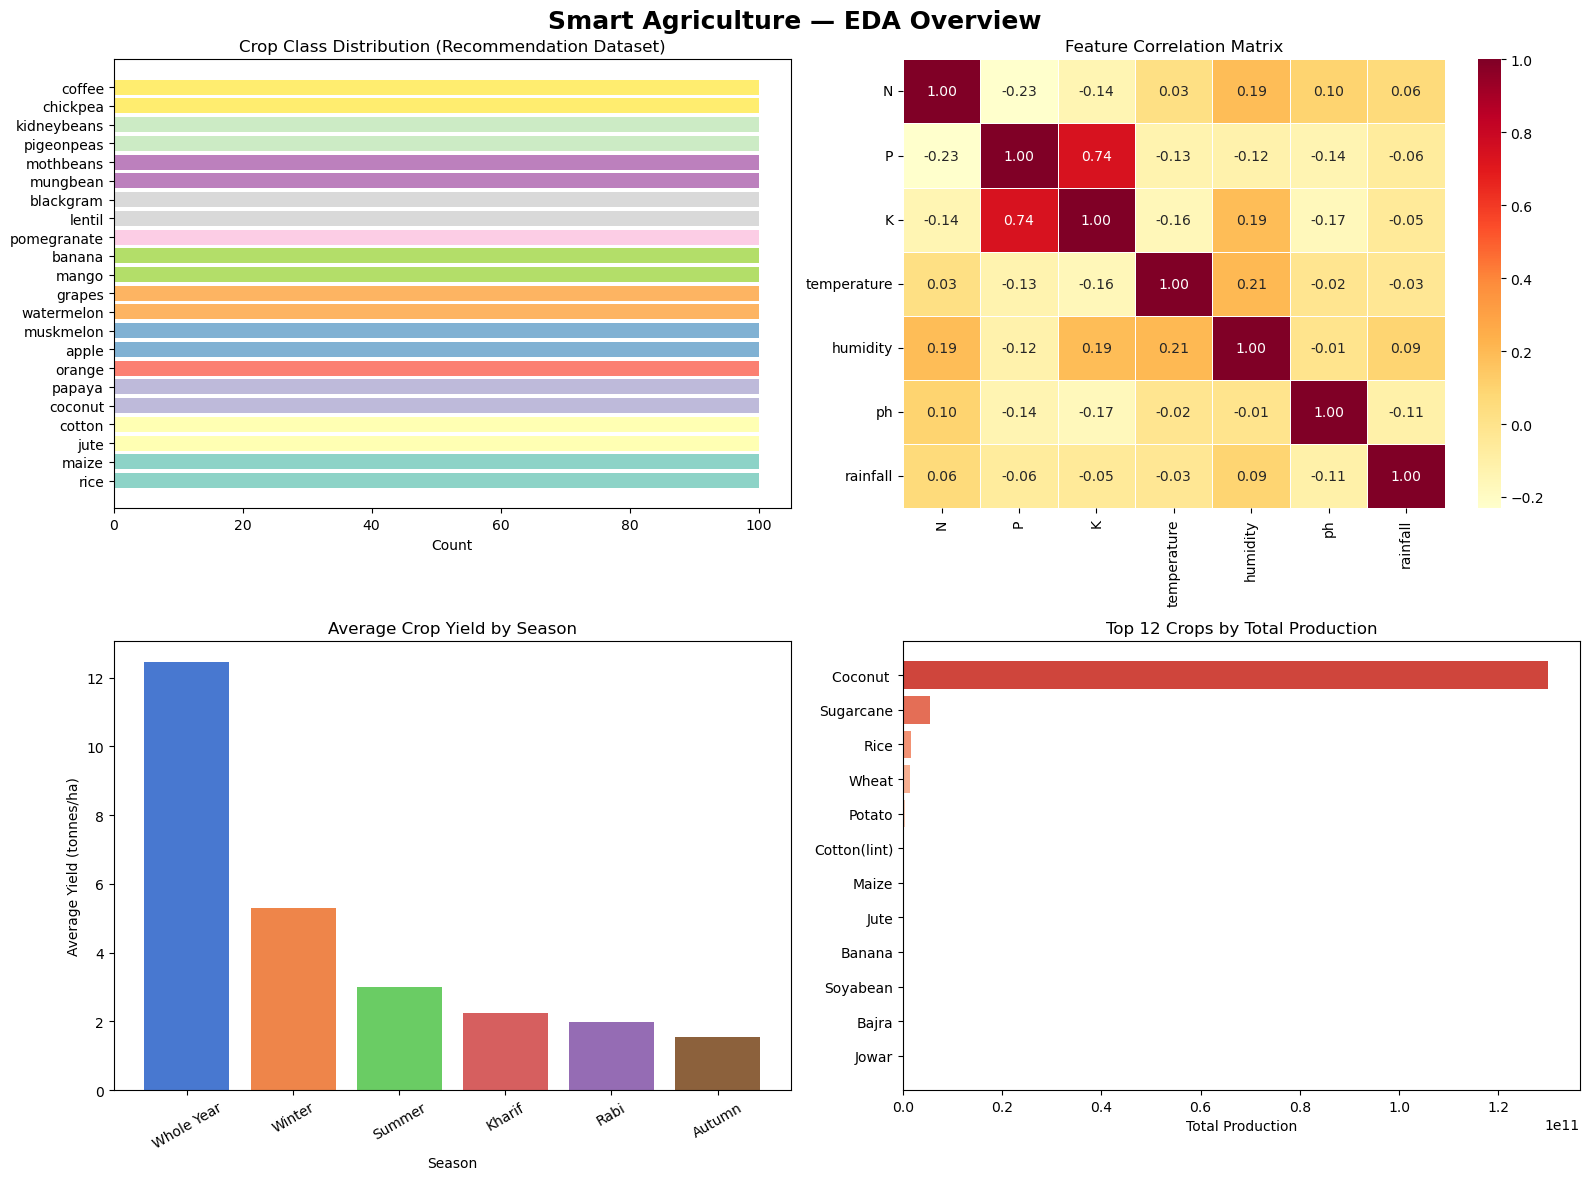

✅ EDA chart saved as eda_overview.png


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Smart Agriculture — EDA Overview", fontsize=18, fontweight="bold")
 
# 4A. Crop class distribution
crop_counts = rec_df["label"].value_counts()
axes[0, 0].barh(crop_counts.index, crop_counts.values,
                color=plt.cm.Set3(np.linspace(0, 1, len(crop_counts))))
axes[0, 0].set_title("Crop Class Distribution (Recommendation Dataset)")
axes[0, 0].set_xlabel("Count")
 
# 4B. Feature correlation heatmap
num_cols = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
corr = rec_df[num_cols].corr()
sns.heatmap(corr, ax=axes[0, 1], annot=True, fmt=".2f",
            cmap="YlOrRd", linewidths=0.5)
axes[0, 1].set_title("Feature Correlation Matrix")
 
# 4C. Season-wise yield distribution
season_yield = yield_df.groupby("Season")["Yield"].mean().sort_values(ascending=False)
axes[1, 0].bar(season_yield.index, season_yield.values,
               color=sns.color_palette("muted", len(season_yield)))
axes[1, 0].set_title("Average Crop Yield by Season")
axes[1, 0].set_xlabel("Season")
axes[1, 0].set_ylabel("Average Yield (tonnes/ha)")
axes[1, 0].tick_params(axis="x", rotation=30)
 
# 4D. Top crops by production
top_crops = prod_df.groupby("Crop")["Production"].sum().nlargest(12)
axes[1, 1].barh(top_crops.index[::-1], top_crops.values[::-1],
                color=sns.color_palette("coolwarm", 12))
axes[1, 1].set_title("Top 12 Crops by Total Production")
axes[1, 1].set_xlabel("Total Production")
 
plt.tight_layout()
plt.savefig("eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ EDA chart saved as eda_overview.png")

In [5]:

rec_enc = rec_df.copy()
 
# Label-encode the target
le_crop = LabelEncoder()
rec_enc["crop_encoded"] = le_crop.fit_transform(rec_enc["label"])
 
X_cls = rec_enc[["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]].values
y_cls = rec_enc["crop_encoded"].values
 
# 80/20 train-test split  (stratified so every crop appears in both sets)
X_tr_cls, X_te_cls, y_tr_cls, y_te_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)
 
# Feature scaling (needed for KNN and SVM)
scaler_cls = StandardScaler()
X_tr_cls_sc = scaler_cls.fit_transform(X_tr_cls)
X_te_cls_sc  = scaler_cls.transform(X_te_cls)
 
print(f"✅ Classification data ready")
print(f"   Train: {X_tr_cls.shape}   Test: {X_te_cls.shape}")
print(f"   Classes ({len(le_crop.classes_)}): {list(le_crop.classes_)}")

✅ Classification data ready
   Train: (1760, 7)   Test: (440, 7)
   Classes (22): ['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee', 'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize', 'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'pomegranate', 'rice', 'watermelon']


In [6]:
yield_enc = yield_df.copy()
 
cat_cols_yield = ["Crop", "Season", "State"]
le_dict_yield  = {}
for col in cat_cols_yield:
    le = LabelEncoder()
    yield_enc[col] = le.fit_transform(yield_enc[col].astype(str))
    le_dict_yield[col] = le
 
reg_features = ["Crop", "Crop_Year", "Season", "State",
                "Area", "Annual_Rainfall", "Fertilizer", "Pesticide"]
X_reg = yield_enc[reg_features].values
y_reg = yield_enc["Yield"].values
 
X_tr_reg, X_te_reg, y_tr_reg, y_te_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)
 
scaler_reg = StandardScaler()
X_tr_reg_sc = scaler_reg.fit_transform(X_tr_reg)
X_te_reg_sc  = scaler_reg.transform(X_te_reg)
 
print(f"✅ Regression data ready")
print(f"   Train: {X_tr_reg.shape}   Test: {X_te_reg.shape}")
print(f"   Target range: {y_reg.min():.3f} – {y_reg.max():.3f}")

✅ Regression data ready
   Train: (15593, 8)   Test: (3899, 8)
   Target range: 0.000 – 104.221


In [7]:
cls_results = {}
 
# 7A. Logistic Regression (Linear baseline for classification)
lr_cls = LogisticRegression(max_iter=1000, random_state=42)
lr_cls.fit(X_tr_cls_sc, y_tr_cls)
cls_results["Logistic Regression"] = accuracy_score(y_te_cls, lr_cls.predict(X_te_cls_sc))
 
# 7B. Decision Tree Classifier
dt_cls = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_cls.fit(X_tr_cls, y_tr_cls)
cls_results["Decision Tree"] = accuracy_score(y_te_cls, dt_cls.predict(X_te_cls))
 
# 7C. Random Forest Classifier
rf_cls = RandomForestClassifier(n_estimators=100, random_state=42)
rf_cls.fit(X_tr_cls, y_tr_cls)
cls_results["Random Forest"] = accuracy_score(y_te_cls, rf_cls.predict(X_te_cls))
 
# 7D. KNN Classifier
knn_cls = KNeighborsClassifier(n_neighbors=5)
knn_cls.fit(X_tr_cls_sc, y_tr_cls)
cls_results["KNN"] = accuracy_score(y_te_cls, knn_cls.predict(X_te_cls_sc))
 
# 7E. SVM Classifier
svm_cls = SVC(kernel="rbf", probability=True, random_state=42)
svm_cls.fit(X_tr_cls_sc, y_tr_cls)
cls_results["SVM"] = accuracy_score(y_te_cls, svm_cls.predict(X_te_cls_sc))
 
# Print results table
print(f"\n{'='*40}")
print(f"  {'Model':<22} {'Accuracy':>8}")
print(f"  {'-'*30}")
for model, acc in sorted(cls_results.items(), key=lambda x: -x[1]):
    print(f"  {model:<22} {acc*100:>7.2f}%")
 
best_cls_name = max(cls_results, key=cls_results.get)
print(f"\n  🏆 Best Classifier: {best_cls_name}  ({cls_results[best_cls_name]*100:.2f}%)")


  Model                  Accuracy
  ------------------------------
  Random Forest            99.55%
  SVM                      98.41%
  KNN                      97.95%
  Logistic Regression      97.27%
  Decision Tree            96.36%

  🏆 Best Classifier: Random Forest  (99.55%)


In [8]:
### CELL 8 — Train ALL Regression Models ###

import numpy as np

def reg_metrics(y_true, y_pred):
    """Return R², RMSE, MAE as a formatted string."""
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return r2, rmse, mae

reg_results = {}

# 8A. Linear Regression
lr_reg = LinearRegression()
lr_reg.fit(X_tr_reg_sc, y_tr_reg)
reg_results["Linear Regression"] = reg_metrics(y_te_reg, lr_reg.predict(X_te_reg_sc))

# 8B. Decision Tree Regressor
dt_reg = DecisionTreeRegressor(max_depth=10, random_state=42)
dt_reg.fit(X_tr_reg, y_tr_reg)
reg_results["Decision Tree"] = reg_metrics(y_te_reg, dt_reg.predict(X_te_reg))

# 8C. Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_tr_reg, y_tr_reg)
reg_results["Random Forest"] = reg_metrics(y_te_reg, rf_reg.predict(X_te_reg))

# 8D. KNN Regressor
knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_tr_reg_sc, y_tr_reg)
reg_results["KNN"] = reg_metrics(y_te_reg, knn_reg.predict(X_te_reg_sc))

# 8E. SVR (Support Vector Regressor)
svr = SVR(kernel="rbf")
svr.fit(X_tr_reg_sc, y_tr_reg)
reg_results["SVR"] = reg_metrics(y_te_reg, svr.predict(X_te_reg_sc))

# Print results table
print(f"\n{'='*60}")
print(f"  {'Model':<22} {'R²':>6}  {'RMSE':>8}  {'MAE':>8}")
print(f"  {'-'*50}")
for model, (r2, rmse, mae) in sorted(reg_results.items(), key=lambda x: -x[1][0]):
    print(f"  {model:<22} {r2:>6.4f}  {rmse:>8.4f}  {mae:>8.4f}")

best_reg_name = max(reg_results, key=lambda x: reg_results[x][0])
print(f"\n  🏆 Best Regressor: {best_reg_name}  (R² = {reg_results[best_reg_name][0]:.4f})")


  Model                      R²      RMSE       MAE
  --------------------------------------------------
  Random Forest          0.9442    2.5878    0.7653
  Decision Tree          0.8883    3.6613    1.2286
  KNN                    0.5364    7.4591    3.0472
  Linear Regression      0.1182   10.2869    4.9505
  SVR                    0.0387   10.7405    3.3404

  🏆 Best Regressor: Random Forest  (R² = 0.9442)


✅ ANN Classifier trained
   Test Accuracy : 98.18%
   Epochs run    : 74


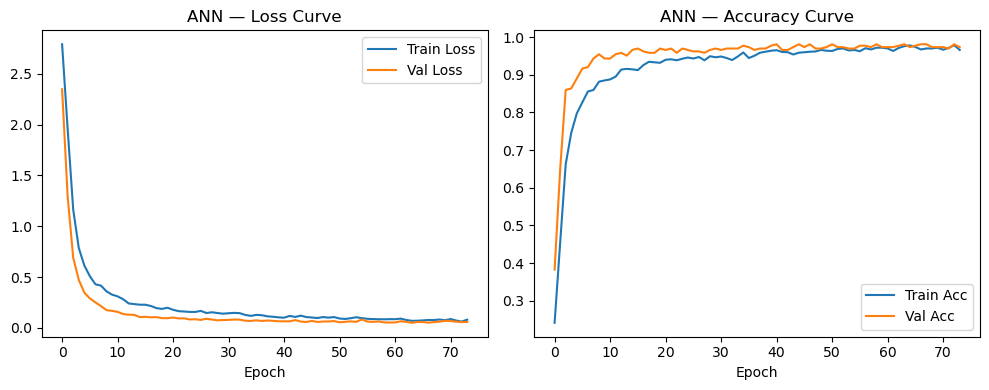

In [9]:
n_classes = len(le_crop.classes_)
 
# One-hot encode targets for ANN
y_tr_onehot = to_categorical(y_tr_cls, num_classes=n_classes)
y_te_onehot = to_categorical(y_te_cls, num_classes=n_classes)
 
ann_cls = Sequential([
    Dense(128, activation="relu", input_shape=(X_tr_cls_sc.shape[1],)),
    Dropout(0.3),
    Dense(64,  activation="relu"),
    Dropout(0.2),
    Dense(32,  activation="relu"),
    Dense(n_classes, activation="softmax")
])
 
ann_cls.compile(optimizer="adam",
                loss="categorical_crossentropy",
                metrics=["accuracy"])
 
es = EarlyStopping(patience=10, restore_best_weights=True, verbose=0)
 
history_ann_cls = ann_cls.fit(
    X_tr_cls_sc, y_tr_onehot,
    validation_split=0.15,
    epochs=80, batch_size=32,
    callbacks=[es], verbose=0
)
 
ann_cls_acc = ann_cls.evaluate(X_te_cls_sc, y_te_onehot, verbose=0)[1]
print(f"✅ ANN Classifier trained")
print(f"   Test Accuracy : {ann_cls_acc*100:.2f}%")
print(f"   Epochs run    : {len(history_ann_cls.history['loss'])}")
 
# Plot training curves
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_ann_cls.history["loss"],     label="Train Loss")
plt.plot(history_ann_cls.history["val_loss"], label="Val Loss")
plt.title("ANN — Loss Curve")
plt.xlabel("Epoch"); plt.legend()
 
plt.subplot(1, 2, 2)
plt.plot(history_ann_cls.history["accuracy"],     label="Train Acc")
plt.plot(history_ann_cls.history["val_accuracy"], label="Val Acc")
plt.title("ANN — Accuracy Curve")
plt.xlabel("Epoch"); plt.legend()
plt.tight_layout()
plt.savefig("ann_training.png", dpi=150); plt.show()

In [10]:
X_tr_cnn = X_tr_cls_sc.reshape(-1, 7, 1)
X_te_cnn = X_te_cls_sc.reshape(-1, 7, 1)
 
cnn_cls = Sequential([
    Conv1D(32, kernel_size=3, activation="relu", padding="same", input_shape=(7, 1)),
    MaxPooling1D(pool_size=2, padding="same"),
    Conv1D(64, kernel_size=3, activation="relu", padding="same"),
    Flatten(),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(n_classes, activation="softmax")
])
 
cnn_cls.compile(optimizer="adam",
                loss="categorical_crossentropy",
                metrics=["accuracy"])
 
history_cnn_cls = cnn_cls.fit(
    X_tr_cnn, y_tr_onehot,
    validation_split=0.15,
    epochs=80, batch_size=32,
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True, verbose=0)],
    verbose=0
)
 
cnn_cls_acc = cnn_cls.evaluate(X_te_cnn, y_te_onehot, verbose=0)[1]
print(f"✅ 1D-CNN Classifier trained")
print(f"   Test Accuracy : {cnn_cls_acc*100:.2f}%")
print(f"   Epochs run    : {len(history_cnn_cls.history['loss'])}")

✅ 1D-CNN Classifier trained
   Test Accuracy : 98.18%
   Epochs run    : 66


In [11]:
import numpy as np

ann_reg = Sequential([
    Dense(128, activation="relu", input_shape=(X_tr_reg_sc.shape[1],)),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1, activation="linear")
])

ann_reg.compile(optimizer="adam", loss="mse", metrics=["mae"])

history_ann_reg = ann_reg.fit(
    X_tr_reg_sc, y_tr_reg,
    validation_split=0.15,
    epochs=80,
    batch_size=64,
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True, verbose=0)],
    verbose=0
)

y_pred_ann_reg = ann_reg.predict(X_te_reg_sc).flatten()

ann_r2 = r2_score(y_te_reg, y_pred_ann_reg)
ann_rmse = np.sqrt(mean_squared_error(y_te_reg, y_pred_ann_reg))

print("✅ ANN Regressor trained")
print(f"   R²   : {ann_r2:.4f}")
print(f"   RMSE : {ann_rmse:.4f}")

122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
✅ ANN Regressor trained
   R²   : 0.6186
   RMSE : 6.7650


In [12]:
X_tr_cnn_reg = X_tr_reg_sc.reshape(-1, 8, 1)
X_te_cnn_reg = X_te_reg_sc.reshape(-1, 8, 1)

cnn_reg = Sequential([
    Conv1D(32, kernel_size=3, activation="relu", padding="same", input_shape=(8, 1)),
    MaxPooling1D(pool_size=2, padding="same"),
    Conv1D(64, kernel_size=3, activation="relu", padding="same"),
    Flatten(),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="linear")
])

cnn_reg.compile(optimizer="adam", loss="mse", metrics=["mae"])

history_cnn_reg = cnn_reg.fit(
    X_tr_cnn_reg, y_tr_reg,
    validation_split=0.15,
    epochs=80,
    batch_size=64,
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True, verbose=0)],
    verbose=0
)

y_pred_cnn_reg = cnn_reg.predict(X_te_cnn_reg).flatten()

cnn_r2 = r2_score(y_te_reg, y_pred_cnn_reg)
cnn_rmse = np.sqrt(mean_squared_error(y_te_reg, y_pred_cnn_reg))

print("✅ 1D-CNN Regressor trained")
print(f"   R²   : {cnn_r2:.4f}")
print(f"   RMSE : {cnn_rmse:.4f}")

122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
✅ 1D-CNN Regressor trained
   R²   : 0.7250
   RMSE : 5.7446


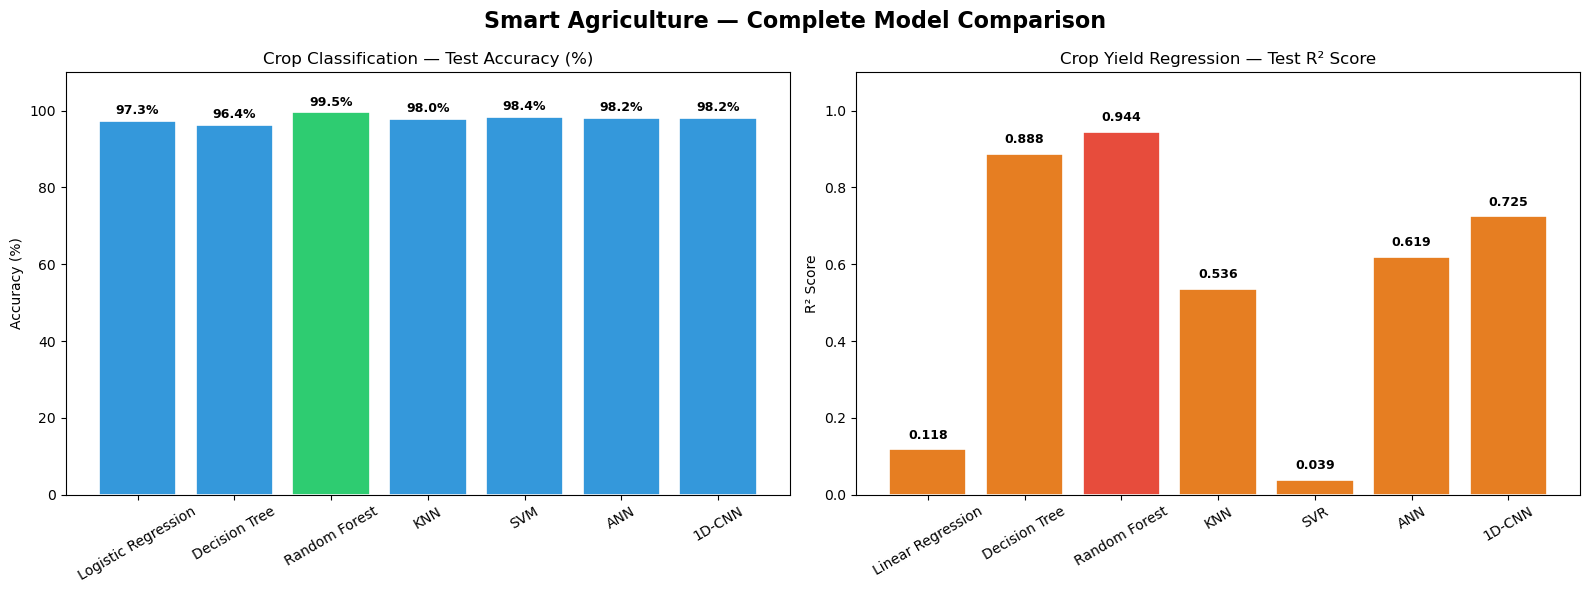

✅ Model comparison chart saved.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Smart Agriculture — Complete Model Comparison", fontsize=16, fontweight="bold")
 
# 13A. Classification Accuracy Bar Chart
all_cls = dict(cls_results)
all_cls["ANN"] = ann_cls_acc
all_cls["1D-CNN"] = cnn_cls_acc
cls_names = list(all_cls.keys())
cls_accs  = [v * 100 for v in all_cls.values()]
colors_cls = ["#2ECC71" if v == max(cls_accs) else "#3498DB" for v in cls_accs]
 
bars = axes[0].bar(cls_names, cls_accs, color=colors_cls, edgecolor="white", linewidth=1.2)
axes[0].set_title("Crop Classification — Test Accuracy (%)")
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_ylim(0, 110)
axes[0].tick_params(axis="x", rotation=30)
for bar, acc in zip(bars, cls_accs):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 f"{acc:.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")
 
# 13B. Regression R² Bar Chart
all_reg = {k: v[0] for k, v in reg_results.items()}
all_reg["ANN"] = ann_r2
all_reg["1D-CNN"] = cnn_r2
reg_names = list(all_reg.keys())
reg_r2s   = list(all_reg.values())
colors_reg = ["#E74C3C" if v == max(reg_r2s) else "#E67E22" for v in reg_r2s]
 
bars2 = axes[1].bar(reg_names, reg_r2s, color=colors_reg, edgecolor="white", linewidth=1.2)
axes[1].set_title("Crop Yield Regression — Test R² Score")
axes[1].set_ylabel("R² Score")
axes[1].set_ylim(0, 1.1)
axes[1].tick_params(axis="x", rotation=30)
for bar, r2 in zip(bars2, reg_r2s):
    axes[1].text(bar.get_x() + bar.get_width() / 2, r2 + 0.02,
                 f"{r2:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
 
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Model comparison chart saved.")

In [14]:
SAVE_DIR = "models"
os.makedirs(SAVE_DIR, exist_ok=True)

# Classification models
joblib.dump(lr_cls,   f"{SAVE_DIR}/lr_cls.pkl")
joblib.dump(dt_cls,   f"{SAVE_DIR}/dt_cls.pkl")
joblib.dump(rf_cls,   f"{SAVE_DIR}/rf_cls.pkl")
joblib.dump(knn_cls,  f"{SAVE_DIR}/knn_cls.pkl")
joblib.dump(svm_cls,  f"{SAVE_DIR}/svm_cls.pkl")
ann_cls.save(f"{SAVE_DIR}/ann_cls.keras")   # ✅ changed from .h5
cnn_cls.save(f"{SAVE_DIR}/cnn_cls.keras")   # ✅ changed from .h5

# Regression models
joblib.dump(lr_reg,   f"{SAVE_DIR}/lr_reg.pkl")
joblib.dump(dt_reg,   f"{SAVE_DIR}/dt_reg.pkl")
joblib.dump(rf_reg,   f"{SAVE_DIR}/rf_reg.pkl")
joblib.dump(knn_reg,  f"{SAVE_DIR}/knn_reg.pkl")
joblib.dump(svr,      f"{SAVE_DIR}/svr.pkl")
ann_reg.save(f"{SAVE_DIR}/ann_reg.keras")   # ✅ changed from .h5
cnn_reg.save(f"{SAVE_DIR}/cnn_reg.keras")   # ✅ changed from .h5

# Encoders and scalers
joblib.dump(le_crop,       f"{SAVE_DIR}/le_crop.pkl")
joblib.dump(le_dict_yield, f"{SAVE_DIR}/le_dict_yield.pkl")
joblib.dump(scaler_cls,    f"{SAVE_DIR}/scaler_cls.pkl")
joblib.dump(scaler_reg,    f"{SAVE_DIR}/scaler_reg.pkl")

print("✅ All models, encoders, and scalers saved to:", SAVE_DIR)
print("   Files saved:")
for f in sorted(os.listdir(SAVE_DIR)):
    print(f"     {f}")

✅ All models, encoders, and scalers saved to: models
   Files saved:
     ann_cls.keras
     ann_reg.keras
     cnn_cls.keras
     cnn_reg.keras
     dt_cls.pkl
     dt_reg.pkl
     knn_cls.pkl
     knn_reg.pkl
     le_crop.pkl
     le_dict_yield.pkl
     lr_cls.pkl
     lr_reg.pkl
     rf_cls.pkl
     rf_reg.pkl
     scaler_cls.pkl
     scaler_reg.pkl
     svm_cls.pkl
     svr.pkl


## 🌾 Prediction Engine

### ⚠️ Important: Input Value Ranges

The `recommend_crops()` function expects values **matching the Crop_recommendation dataset scale**:

| Feature | Valid Range | Unit / Notes |
|---|---|---|
| `n` (Nitrogen) | 0 – 140 | kg/ha |
| `p` (Phosphorus) | 5 – 145 | kg/ha |
| `k` (Potassium) | 5 – 205 | kg/ha |
| `temperature` | 8 – 44 | °C |
| `humidity` | 14 – 100 | % (not fraction) |
| `ph` | 3.5 – 9.9 | soil pH |
| `rainfall` | 20 – 298 | mm — **dataset scale, NOT annual total** |

> **Rainfall note:** The dataset uses small per-period mm values (20–298). If you enter true annual rainfall (e.g. 650 mm for Punjab), the StandardScaler will treat it as an extreme outlier and predictions will be wrong. Divide your annual rainfall by ~4–5 to get an approximate value in the dataset's scale.


In [16]:
CROP_ECONOMICS = {
    "rice":        {"cost": 35000, "profit": 25000, "market": "₹18–22/kg"},
    "maize":       {"cost": 28000, "profit": 20000, "market": "₹15–18/kg"},
    "chickpea":    {"cost": 22000, "profit": 30000, "market": "₹45–60/kg"},
    "kidneybeans": {"cost": 24000, "profit": 28000, "market": "₹60–80/kg"},
    "pigeonpeas":  {"cost": 20000, "profit": 26000, "market": "₹50–65/kg"},
    "mothbeans":   {"cost": 18000, "profit": 22000, "market": "₹40–55/kg"},
    "mungbean":    {"cost": 20000, "profit": 25000, "market": "₹55–70/kg"},
    "blackgram":   {"cost": 19000, "profit": 24000, "market": "₹55–70/kg"},
    "lentil":      {"cost": 21000, "profit": 27000, "market": "₹50–65/kg"},
    "pomegranate": {"cost": 60000, "profit": 90000, "market": "₹50–80/kg"},
    "banana":      {"cost": 50000, "profit": 70000, "market": "₹15–30/kg"},
    "mango":       {"cost": 40000, "profit": 60000, "market": "₹30–80/kg"},
    "grapes":      {"cost": 80000, "profit": 120000, "market": "₹40–100/kg"},
    "watermelon":  {"cost": 30000, "profit": 35000, "market": "₹8–15/kg"},
    "muskmelon":   {"cost": 28000, "profit": 32000, "market": "₹10–20/kg"},
    "apple":       {"cost": 70000, "profit": 100000, "market": "₹60–150/kg"},
    "orange":      {"cost": 45000, "profit": 65000, "market": "₹20–50/kg"},
    "papaya":      {"cost": 35000, "profit": 50000, "market": "₹12–25/kg"},
    "coconut":     {"cost": 25000, "profit": 40000, "market": "₹15–30/piece"},
    "cotton":      {"cost": 35000, "profit": 30000, "market": "₹55–75/kg"},
    "jute":        {"cost": 20000, "profit": 18000, "market": "₹35–50/kg"},
    "coffee":      {"cost": 55000, "profit": 80000, "market": "₹80–150/kg"},
}
 
CROP_REQUIREMENTS = {
    "rice":        {"Water": "High (1200–2000 mm)", "Soil": "Clay/Loamy", "Season": "Kharif",
                   "Fertilizer": "Urea + DAP", "Tools": "Tractor, Transplanter, Harvester"},
    "maize":       {"Water": "Moderate (500–800 mm)", "Soil": "Sandy Loam", "Season": "Kharif/Rabi",
                   "Fertilizer": "17-17-17 NPK", "Tools": "Seed Drill, Sprayer"},
    "chickpea":    {"Water": "Low (300–400 mm)", "Soil": "Sandy/Loamy", "Season": "Rabi",
                   "Fertilizer": "DAP + Rhizobium", "Tools": "Seed Drill, Sprayer"},
    "kidneybeans": {"Water": "Moderate (600 mm)", "Soil": "Loamy", "Season": "Kharif",
                   "Fertilizer": "10-26-26 NPK", "Tools": "Sprayer, Harvester"},
    "pigeonpeas":  {"Water": "Low–Moderate (600 mm)", "Soil": "Sandy/Red", "Season": "Kharif",
                   "Fertilizer": "DAP", "Tools": "Sprayer"},
    "mothbeans":   {"Water": "Low (200–350 mm)", "Soil": "Sandy", "Season": "Kharif",
                   "Fertilizer": "20-20 NPK", "Tools": "Sprayer"},
    "mungbean":    {"Water": "Low–Moderate (400 mm)", "Soil": "Sandy Loam", "Season": "Summer/Kharif",
                   "Fertilizer": "DAP", "Tools": "Sprayer"},
    "blackgram":   {"Water": "Moderate (500 mm)", "Soil": "Loamy/Clay", "Season": "Kharif/Rabi",
                   "Fertilizer": "DAP", "Tools": "Sprayer"},
    "lentil":      {"Water": "Low (350 mm)", "Soil": "Sandy Loam", "Season": "Rabi",
                   "Fertilizer": "20-20 NPK", "Tools": "Sprayer"},
    "pomegranate": {"Water": "Low (500 mm)", "Soil": "Sandy Loam/Red", "Season": "Whole Year",
                   "Fertilizer": "17-17-17 NPK", "Tools": "Drip Irrigation, Sprayer"},
    "banana":      {"Water": "High (1000 mm)", "Soil": "Loamy/Black", "Season": "Whole Year",
                   "Fertilizer": "Urea + MOP", "Tools": "Drip Irrigation"},
    "mango":       {"Water": "Moderate (750 mm)", "Soil": "Loamy/Sandy", "Season": "Summer",
                   "Fertilizer": "17-17-17 NPK", "Tools": "Sprayer"},
    "grapes":      {"Water": "Moderate (700 mm)", "Soil": "Sandy Loam", "Season": "Rabi",
                   "Fertilizer": "14-35-14 NPK", "Tools": "Drip Irrigation, Pruner"},
    "watermelon":  {"Water": "Moderate (400–600 mm)", "Soil": "Sandy", "Season": "Summer",
                   "Fertilizer": "20-20 NPK", "Tools": "Drip Irrigation, Sprayer"},
    "muskmelon":   {"Water": "Moderate (400 mm)", "Soil": "Sandy/Loamy", "Season": "Summer",
                   "Fertilizer": "20-20 NPK", "Tools": "Sprayer"},
    "apple":       {"Water": "Moderate (900 mm)", "Soil": "Loamy", "Season": "Winter/Whole Year",
                   "Fertilizer": "17-17-17 NPK", "Tools": "Sprayer, Cold Storage"},
    "orange":      {"Water": "Moderate (600–700 mm)", "Soil": "Sandy Loam", "Season": "Rabi",
                   "Fertilizer": "17-17-17 NPK", "Tools": "Sprayer"},
    "papaya":      {"Water": "Moderate (800 mm)", "Soil": "Sandy Loam/Loamy", "Season": "Whole Year",
                   "Fertilizer": "Urea + MOP", "Tools": "Drip Irrigation"},
    "coconut":     {"Water": "High (1000–2500 mm)", "Soil": "Loamy/Sandy", "Season": "Whole Year",
                   "Fertilizer": "Urea + DAP", "Tools": "Sprayer"},
    "cotton":      {"Water": "Moderate (500–700 mm)", "Soil": "Black/Loamy", "Season": "Kharif",
                   "Fertilizer": "14-35-14 NPK", "Tools": "Sprayer, Picker"},
    "jute":        {"Water": "High (1000–1500 mm)", "Soil": "Loamy/Sandy", "Season": "Kharif",
                   "Fertilizer": "Urea", "Tools": "Harvester"},
    "coffee":      {"Water": "High (1500 mm)", "Soil": "Red/Loamy", "Season": "Whole Year",
                   "Fertilizer": "17-17-17 NPK", "Tools": "Sprayer, Pulper"},
}
 
def get_fertilizer_recommendation(temp, humidity, moisture, soil_type, crop_type):
    """Look up recommended fertilizer from fertilizer dataset."""
    mask = (
        (fert_df["Soil Type"].str.lower() == soil_type.lower()) &
        (fert_df["Crop Type"].str.lower() == crop_type.lower())
    )
    subset = fert_df[mask]
    if not subset.empty:
        # Return most common fertilizer for this soil + crop combo
        return subset["Fertilizer Name"].mode()[0]
    return "Urea (default)"
 
def get_yield_prediction(model_name, crop_name, year, season,
                         state, area, rainfall, fertilizer, pesticide):
    """Predict yield for the given crop and conditions using selected regressor."""
    # Encode using stored label encoders
    try:
        crop_enc  = le_dict_yield["Crop"].transform([crop_name])[0]
        season_enc = le_dict_yield["Season"].transform([season])[0]
        state_enc  = le_dict_yield["State"].transform([state])[0]
    except ValueError:
        return None     # unseen label – gracefully return None
 
    feat = np.array([[crop_enc, year, season_enc, state_enc,
                      area, rainfall, fertilizer, pesticide]])
 
    model_map = {
        "Linear Regression": (lr_reg,  True),
        "Decision Tree":     (dt_reg,  False),
        "Random Forest":     (rf_reg,  False),
        "KNN":               (knn_reg, True),
        "SVR":               (svr,     True),
        "ANN":               (ann_reg, True),
        "1D-CNN":            (cnn_reg, True),
    }
    if model_name not in model_map:
        return None
 
    mdl, needs_scaling = model_map[model_name]
    if needs_scaling:
        feat = scaler_reg.transform(feat)
    if model_name == "1D-CNN":
        feat = feat.reshape(-1, 8, 1)
        return float(mdl.predict(feat)[0][0])
    if model_name == "ANN":
        return float(mdl.predict(feat)[0][0])
    return float(mdl.predict(feat)[0])
 
def recommend_crops(n, p, k, temperature, humidity, ph, rainfall,
                    land_area_ha, cls_model_name="Random Forest", top_n=3):
    """
    Main prediction function with input validation.
    Returns top_n crop recommendations with economics, yield, and requirements.

    Expected input ranges (must match Crop_recommendation dataset):
      N          : 0  – 140   (Nitrogen, kg/ha)
      P          : 5  – 145   (Phosphorus, kg/ha)
      K          : 5  – 205   (Potassium, kg/ha)
      temperature: 8  – 44    (°C)
      humidity   : 14 – 100   (%)
      ph         : 3.5 – 9.9  (soil pH)
      rainfall   : 20 – 298   (mm — dataset scale, NOT annual total)
    """
    # ── INPUT VALIDATION ────────────────────────────────────────────────────
    FEATURE_RANGES = {
        "N":           (0,   140,  "Nitrogen (kg/ha)"),
        "P":           (5,   145,  "Phosphorus (kg/ha)"),
        "K":           (5,   205,  "Potassium (kg/ha)"),
        "temperature": (8,   44,   "Temperature (°C)"),
        "humidity":    (14,  100,  "Humidity (%)"),
        "ph":          (3.5, 9.9,  "Soil pH"),
        "rainfall":    (20,  298,  "Rainfall (mm) — use dataset scale, not annual total"),
    }
    inputs_check = dict(N=n, P=p, K=k, temperature=temperature,
                        humidity=humidity, ph=ph, rainfall=rainfall)
    warnings_list = []
    for key, val in inputs_check.items():
        lo, hi, label = FEATURE_RANGES[key]
        if not (lo <= val <= hi):
            warnings_list.append(
                f"⚠️  {label} = {val} is outside expected range [{lo}, {hi}]."
            )
    if warnings_list:
        print("INPUT WARNINGS (out-of-range values may cause wrong predictions):")
        for w in warnings_list:
            print("  ", w)
        print()
    # ────────────────────────────────────────────────────────────────────────

    feat  = np.array([[n, p, k, temperature, humidity, ph, rainfall]])
    feat_scaled = scaler_cls.transform(feat)

    cls_model_map = {
        "Logistic Regression": (lr_cls,  True),
        "Decision Tree":       (dt_cls,  False),
        "Random Forest":       (rf_cls,  False),
        "KNN":                 (knn_cls, True),
        "SVM":                 (svm_cls, True),
        "ANN":                 (ann_cls, True),
        "1D-CNN":              (cnn_cls, True),
    }

    if cls_model_name not in cls_model_map:
        raise ValueError(f"Unknown model '{cls_model_name}'. "
                         f"Choose from: {list(cls_model_map.keys())}")

    mdl, needs_scale = cls_model_map[cls_model_name]

    if cls_model_name == "ANN":
        proba = mdl.predict(feat_scaled)[0]
    elif cls_model_name == "1D-CNN":
        proba = mdl.predict(feat_scaled.reshape(-1, 7, 1))[0]
    elif needs_scale and hasattr(mdl, "predict_proba"):
        proba = mdl.predict_proba(feat_scaled)[0]
    elif hasattr(mdl, "predict_proba"):
        proba = mdl.predict_proba(feat)[0]
    else:
        pred = mdl.predict(feat_scaled if needs_scale else feat)[0]
        proba = np.zeros(len(le_crop.classes_))
        proba[pred] = 1.0

    top_indices = np.argsort(proba)[::-1][:top_n]
    recommendations = []

    for idx in top_indices:
        crop_name = le_crop.classes_[idx]
        confidence = proba[idx] * 100
        eco = CROP_ECONOMICS.get(crop_name, {"cost": 30000, "profit": 25000, "market": "N/A"})
        req = CROP_REQUIREMENTS.get(crop_name, {})

        total_cost   = eco["cost"]   * land_area_ha
        total_profit = eco["profit"] * land_area_ha
        roi          = (total_profit / total_cost * 100) if total_cost > 0 else 0

        recommendations.append({
            "Crop":          crop_name.title(),
            "Confidence":    round(confidence, 1),
            "Cost/ha":       eco["cost"],
            "Profit/ha":     eco["profit"],
            "Total Cost":    total_cost,
            "Total Profit":  total_profit,
            "ROI (%)":       round(roi, 1),
            "Market Price":  eco["market"],
            "Water Needs":   req.get("Water",      "N/A"),
            "Soil Type":     req.get("Soil",       "N/A"),
            "Best Season":   req.get("Season",     "N/A"),
            "Fertilizer":    req.get("Fertilizer", "N/A"),
            "Tools Needed":  req.get("Tools",      "N/A"),
        })

    return recommendations

print("✅ Prediction engine ready (with input validation).")
print("   Use recommend_crops() to get crop recommendations.")
print()
print("   Valid input ranges:")
print("     N          : 0–140    (Nitrogen, kg/ha)")
print("     P          : 5–145    (Phosphorus, kg/ha)")
print("     K          : 5–205    (Potassium, kg/ha)")
print("     temperature: 8–44 °C")
print("     humidity   : 14–100 %")
print("     ph         : 3.5–9.9")
print("     rainfall   : 20–298 mm  ⚠️ dataset scale — NOT annual total")

✅ Prediction engine ready (with input validation).
   Use recommend_crops() to get crop recommendations.

   Valid input ranges:
     N          : 0–140    (Nitrogen, kg/ha)
     P          : 5–145    (Phosphorus, kg/ha)
     K          : 5–205    (Potassium, kg/ha)
     temperature: 8–44 °C
     humidity   : 14–100 %
     ph         : 3.5–9.9
     rainfall   : 20–298 mm  ⚠️ dataset scale — NOT annual total


In [1]:
sample_result = recommend_crops(
    n=40,              # Nitrogen   (kg/ha) — valid range: 0–140
    p=25,              # Phosphorus (kg/ha) — valid range: 5–145
    k=50,           # Potassium  (kg/ha) — valid range: 5–205
    temperature=25,  # °C               — valid range: 8–44
    humidity=60,     # %                — valid range: 14–100
    ph=6.5,            # soil pH          — valid range: 3.5–9.9
    rainfall=150,    # mm (dataset scale, NOT annual total!) — valid range: 20–298
    land_area_ha=2.5,  # farmer's land in hectares
    cls_model_name="Random Forest",
    top_n=3
)

print("\n" + "="*65)
print("  🌾  SMART AGRICULTURE CROP RECOMMENDATIONS  🌾")
print("="*65)
for i, rec in enumerate(sample_result, 1):
    print(f"\n  Rank #{i} — {rec['Crop']}  (Confidence: {rec['Confidence']}%)")
    print(f"  {'─'*55}")
    print(f"  💰 Cost  per ha  : ₹{rec['Cost/ha']:,.0f}")
    print(f"  📈 Profit per ha : ₹{rec['Profit/ha']:,.0f}")
    print(f"  🏠 Total Cost    : ₹{rec['Total Cost']:,.0f}")
    print(f"  💵 Total Profit  : ₹{rec['Total Profit']:,.0f}")
    print(f"  📊 ROI           : {rec['ROI (%)']:.1f}%")
    print(f"  💹 Market Price  : {rec['Market Price']}")
    print(f"  💧 Water Needs   : {rec['Water Needs']}")
    print(f"  🌱 Soil Type     : {rec['Soil Type']}")
    print(f"  🗓  Best Season   : {rec['Best Season']}")
    print(f"  🧪 Fertilizer    : {rec['Fertilizer']}")
    print(f"  🚜 Tools Needed  : {rec['Tools Needed']}")
print("\n" + "="*65)

### CELL 17 — Confusion Matrix for Best Classifier ###

best_model_for_cm = rf_cls
y_pred_cm = best_model_for_cm.predict(X_te_cls)

cm = confusion_matrix(y_te_cls, y_pred_cm)
plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le_crop.classes_,
            yticklabels=le_crop.classes_,
            linewidths=0.5)
plt.title("Random Forest — Confusion Matrix (Crop Classification)", fontsize=14)
plt.xlabel("Predicted Crop")
plt.ylabel("Actual Crop")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Confusion matrix saved.")

### CELL 18 — Feature Importance (Random Forest) ###

feat_names = ["Nitrogen", "Phosphorus", "Potassium",
              "Temperature", "Humidity", "pH", "Rainfall"]
importances = rf_cls.feature_importances_
sorted_idx  = np.argsort(importances)[::-1]

plt.figure(figsize=(9, 5))
plt.bar([feat_names[i] for i in sorted_idx],
        importances[sorted_idx],
        color=sns.color_palette("viridis", 7))
plt.title("Feature Importance — Random Forest Classifier")
plt.xlabel("Feature")
plt.ylabel("Importance Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Feature importance chart saved.")

NameError: name 'recommend_crops' is not defined

In [18]:
import joblib
import os

SAVE_DIR = "models"
os.makedirs(SAVE_DIR, exist_ok=True)

# ✅ FIXED: Save model + scaler + label encoder together
#    (Previously only rf_cls was saved, making brain.pkl useless standalone)
joblib.dump({
    "model":   rf_cls,      # Random Forest classifier
    "scaler":  scaler_cls,  # StandardScaler fitted on training data
    "encoder": le_crop,     # LabelEncoder to decode class index → crop name
}, 'brain.pkl')

print("✅ brain.pkl saved with model + scaler + label encoder")
print()
print("   To load and use brain.pkl elsewhere:")
print("     import joblib, numpy as np")
print("     bundle = joblib.load('brain.pkl')")
print("     inp    = np.array([[N, P, K, temperature, humidity, pH, rainfall]])")
print("     scaled = bundle['scaler'].transform(inp)")
print("     pred   = bundle['model'].predict(scaled)[0]")
print("     crop   = bundle['encoder'].classes_[pred]")
print("     print('Recommended crop:', crop)")

✅ brain.pkl saved with model + scaler + label encoder

   To load and use brain.pkl elsewhere:
     import joblib, numpy as np
     bundle = joblib.load('brain.pkl')
     inp    = np.array([[N, P, K, temperature, humidity, pH, rainfall]])
     scaled = bundle['scaler'].transform(inp)
     pred   = bundle['model'].predict(scaled)[0]
     crop   = bundle['encoder'].classes_[pred]
     print('Recommended crop:', crop)
